In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns

In [8]:
# Importing test data #
path = "C:/Users/Kolby/OneDrive/Documents/School Stuff/Stat 6543/Poster"
Test_Data = pd.read_csv(path + "/test.csv")
Train_data = pd.read_csv(path + "/train.csv")

In [9]:
print(Train_data.head())
Train_data.shape


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

(1460, 81)

In [10]:
## Exploring NA values ## 

Train_data.isna().sum().sort_values(ascending = False)
NAs = Train_data.isna()
NA_train_data = Train_data[NAs.any(axis = 1)]
NA_train_data.shape

(1460, 81)

In [11]:
Train_data.isna().sum().sort_values(ascending = False).head(10)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
FireplaceQu     690
LotFrontage     259
GarageYrBlt      81
GarageCond       81
GarageType       81
dtype: int64

**NA Heavy Features: Features missing from over 50% of the training data**
* PoolQC - Pool quality
* MiscFeature - Miscellaneous feature not covered in other categories
* Alley - Type of alley access
* Fence - Fence quality
* MasVnrType - Masonry veneer type <br>
**Honorable Mention:**
* FireplaceQu - Fireplace quality

In [12]:
### Handling NA Values ###
## Imputing 'None' for PoolQC where PoolArea is 0. This is because if there is no pool, there cannot be a pool quality rating. ##
Train_data['PoolQC'] = np.where(Train_data['PoolArea'] == 0, 'None', Train_data['PoolQC'])

## Imputing 'None' for MiscFeature where MiscVal is 0. This is because if there is no miscellaneous feature, there cannot be a miscellaneous feature rating. ##
Train_data['MiscFeature'] = np.where(Train_data['MiscVal'] == 0, 'None', Train_data['MiscFeature'])

## Imputing 'None' for MasVnrType where MasVNRArea is 0. This is because if there is no masonry veneer area, there cannot be a masonry veneer type. ##
Train_data['MasVnrType'] = np.where(Train_data['MasVnrArea'] == 0, 'None', Train_data['MasVnrType'])

## Imputing 'None' for alley access where there is no alley access. 
Train_data['Alley'] = np.where(Train_data['Alley'].isna(), 'None', Train_data['Alley'])

## Imputing 'None' for fence where there is no fence. 
Train_data['Fence'] = np.where(Train_data['Fence'].isna(), 'None', Train_data['Fence'])

In [13]:
### Making the same imputations for the test data ###
## Imputing 'None' for PoolQC where PoolArea is 0. This is because if there is no pool, there cannot be a pool quality rating. ##
Test_Data['PoolQC'] = np.where(Test_Data['PoolArea'] == 0, 'None', Test_Data['PoolQC'])

## Imputing 'None' for MiscFeature where MiscVal is 0. This is because if there is no miscellaneous feature, there cannot be a miscellaneous feature rating. ##
Test_Data['MiscFeature'] = np.where(Test_Data['MiscVal'] == 0, 'None', Test_Data['MiscFeature'])

## Imputing 'None' for MasVnrType where MasVNRArea is 0. This is because if there is no masonry veneer area, there cannot be a masonry veneer type. ##
Test_Data['MasVnrType'] = np.where(Test_Data['MasVnrArea'] == 0, 'None', Test_Data['MasVnrType'])

## Imputing 'None' for alley access where there is no alley access. 
Test_Data['Alley'] = np.where(Test_Data['Alley'].isna(), 'None', Test_Data['Alley'])

## Imputing 'None' for fence where there is no fence. 
Test_Data['Fence'] = np.where(Test_Data['Fence'].isna(), 'None', Test_Data['Fence'])

Text(0, 0.5, 'Frequency')

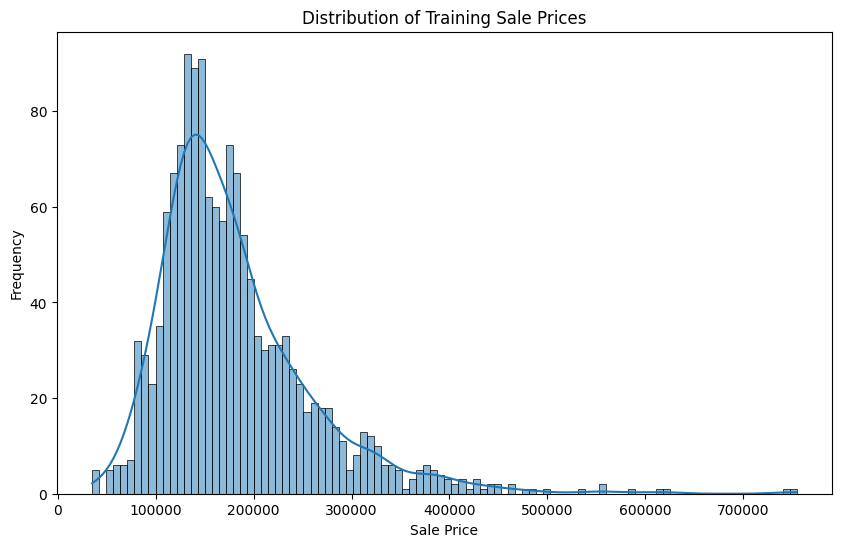

In [66]:
plt.figure(figsize = (10,6))
sns.histplot(Train_data['SalePrice'], bins = 100, kde = True)
plt.title('Distribution of Training Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

In [54]:
## Splitting the data ##
train_set_x = Train_data.drop('SalePrice', axis = 1)
train_set_y = np.log(Train_data['SalePrice'])

train_x, test_x, train_y, test_y = train_test_split(train_set_x, train_set_y, test_size = 0.25, random_state = 12)


In [55]:
## Instantiating the linear model pipeline ##
num_features  = train_x.select_dtypes(include = ['number'] )
cat_features = train_x.select_dtypes(exclude = ['number'])

num_pipe_linear = Pipeline(steps = [
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy = 'median')),  
])
cat_pipe_linear = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore', drop = 'first'))
])

preprocessor_linear = ColumnTransformer(transformers = [
    ('num', num_pipe_linear, num_features.columns),
    ('cat', cat_pipe_linear, cat_features.columns),
])


In [56]:
## Instantiating linear models ## 

ridge = Ridge()
lasso = Lasso()

pg = {
    'model__alpha': np.array([0.01, 0.1, 0.2, 0.25, 0.3])
}

ridge_pipe = Pipeline(steps = [
    ('preprocessor', preprocessor_linear),
    ('model', ridge)
])

lasso_pipe = Pipeline( steps = [
    ('preprocessor', preprocessor_linear),
    ('model', lasso)
])

kf = KFold(n_splits = 5, shuffle = True, random_state= 12)

GRidge = GridSearchCV(estimator = ridge_pipe, param_grid = pg, cv = kf, scoring= 'neg_root_mean_squared_error')
GLasso = GridSearchCV(estimator = lasso_pipe, param_grid = pg, cv = kf, scoring = 'neg_root_mean_squared_error')


In [57]:
## Fitting and predicting linear models ## 
GRidge.fit(train_x, train_y)
GRidge_pred = GRidge.predict(test_x)

GLasso.fit(train_x, train_y)
GLasso_pred = GLasso.predict(test_x)


C:\Users\Kolby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [14, 16, 19, 22, 26, 29, 31, 41] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\Kolby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [8, 10, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\Kolby\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [9, 10, 15, 40] during transform. These unknown categories will be encoded as all zeros
  war

In [58]:
## Scoring the linear models ##
GRidge_rsme = mean_squared_error(test_y, GRidge_pred)
GLasso_rsme = mean_squared_error(test_y, GLasso_pred)

print(f'The RSME for the linear models are Ridge: {GRidge_rsme}, Lasso: {GLasso_rsme}')

GRidge_R2 = r2_score(test_y, GRidge_pred)
GLasso_R2 = r2_score(test_y, GLasso_pred)

print(f'The R2 for the linear models are Ridge: {GRidge_R2}, Lasso: {GLasso_R2}')

ridge_mae = mean_absolute_error(test_y, GRidge_pred)
lasso_mae = mean_absolute_error(test_y, GLasso_pred)

print(f'The MAE for the linear models are Ridge: {ridge_mae}, Lasso: {lasso_mae}')

The RSME for the linear models are Ridge: 0.0473823383350811, Lasso: 0.04528940340186665
The R2 for the linear models are Ridge: 0.7241759627796889, Lasso: 0.7363594425994517
The MAE for the linear models are Ridge: 0.0930912956953094, Lasso: 0.09814953761574863


In [59]:
## Instantiaating Tree Pipelines ##

num_pipe_tree = Pipeline( steps = [
    ('imputer', SimpleImputer(strategy = 'median'))
])

cat_pipe_tree = Pipeline( steps = [
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

preprocessor_tree = ColumnTransformer(transformers = [
    ('num', num_pipe_tree, num_features.columns),
    ('cat', cat_pipe_tree, cat_features.columns)
])



In [60]:
## Instantiating Tree Based Models ## 
rf = RandomForestRegressor()
xgb = XGBRegressor()

rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2,5,10]
}

xgb_param_grid = {
    'model__n_estimators': [200, 250, 300, 350],
    'model__max_depth': [1, 2, 3, 5],
    'model__learning_rate': [0.2, 0.3, 0.4, 0.5]
}

rf_pipe = Pipeline(steps = [
    ('preprocessor', preprocessor_tree),
    ('model', rf)
])

xgb_pipe = Pipeline(steps = [
    ('preprocessor', preprocessor_tree),
    ('model', xgb)
])

kf2 = KFold(n_splits = 3, shuffle = True, random_state= 12)

GS_rf = GridSearchCV(estimator = rf_pipe, param_grid = rf_param_grid, cv = kf2, scoring= 'neg_root_mean_squared_error')
GS_xgb = GridSearchCV(estimator = xgb_pipe, param_grid = xgb_param_grid, cv = kf2, scoring= 'neg_root_mean_squared_error')


In [61]:
## Fitting and predicting tree based models ##
GS_rf.fit(train_x, train_y)
rf_pred = GS_rf.predict(test_x)

In [67]:
GS_xgb.fit(train_x, train_y)
xgb_pred = GS_xgb.predict(test_x)

In [68]:
print(GS_xgb.best_params_)
print(-GS_xgb.best_score_)

{'model__learning_rate': 0.3, 'model__max_depth': 1, 'model__n_estimators': 350}
0.12478621372070041


In [69]:
## Scoring the Tree models ##
from sklearn.metrics import mean_absolute_error

rf_rsme = mean_squared_error(test_y, rf_pred)
xgb_rsme = mean_squared_error(test_y, xgb_pred)

print(f'The RSME for the tree models are RF: {rf_rsme}, XGB: {xgb_rsme}')

rf_R2 = r2_score(test_y, rf_pred)
xgb_R2 = r2_score(test_y, xgb_pred)

print(f'The R2 for the tree models are RF: {rf_R2}, XGB: {xgb_R2}')

rf_mae = mean_absolute_error(test_y, rf_pred)
xgb_mae = mean_absolute_error(test_y, xgb_pred)

print(f'The MAE for the tree models are RF: {rf_mae}, XGB: {xgb_mae}')


The RSME for the tree models are RF: 0.025107877091095774, XGB: 0.024560649908033545
The R2 for the tree models are RF: 0.8538409823440483, XGB: 0.8570265239659393
The MAE for the tree models are RF: 0.1010573151709303, XGB: 0.09666493822601076


In [70]:
## Summary model performance ##
model_performance = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Random Forest', 'XGBoost'],
    'RSME': [GRidge_rsme, GLasso_rsme, rf_rsme, xgb_rsme],
    'R2': [GRidge_R2, GLasso_R2, rf_R2, xgb_R2],
    'MAE': [ridge_mae, lasso_mae, rf_mae, xgb_mae]
})
print(model_performance)

           Model      RSME        R2       MAE
0          Ridge  0.047382  0.724176  0.093091
1          Lasso  0.045289  0.736359  0.098150
2  Random Forest  0.025108  0.853841  0.101057
3        XGBoost  0.024561  0.857027  0.096665


Text(0, 0.5, 'Frequency')

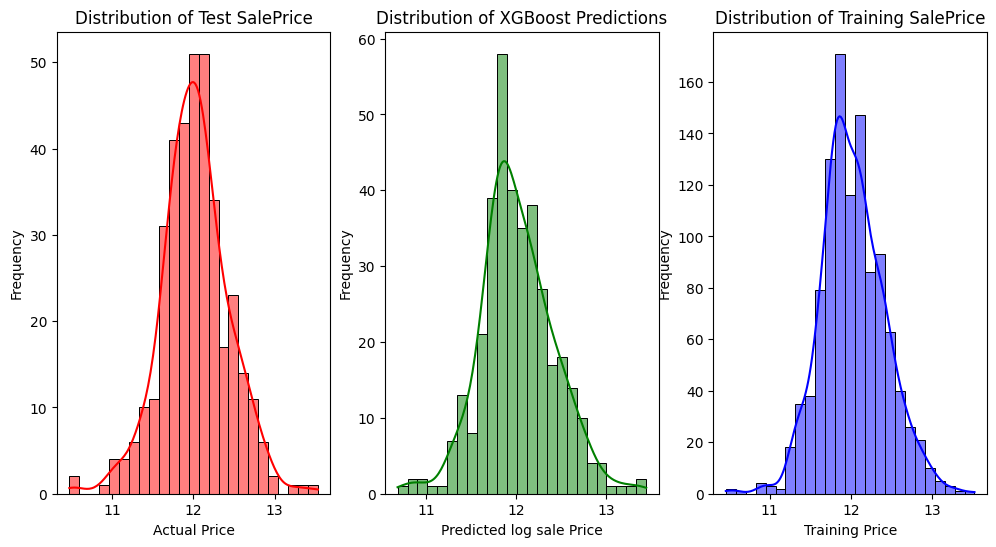

In [89]:
# Side-by-side comparison of predictions vs actuals 
plt.figure(figsize = (12,6))
plt.subplot(1,3,1)
sns.histplot(test_y, bins = 25, kde = True, color = 'red')
plt.title('Distribution of Test SalePrice')
plt.xlabel('Actual Price')
plt.ylabel('Frequency')

plt.subplot(1,3,2)
sns.histplot(xgb_pred, bins = 25, kde = True, color = 'green')
plt.title('Distribution of XGBoost Predictions')
plt.xlabel('Predicted log sale Price')
plt.ylabel('Frequency')

plt.subplot(1,3,3)
sns.histplot(train_y, bins = 25, kde = True, color = 'blue')
plt.title('Distribution of Training SalePrice')
plt.xlabel('Training Price')
plt.ylabel('Frequency')

Text(0.5, 1.0, 'Top 10 Feature Importances from XGBoost')

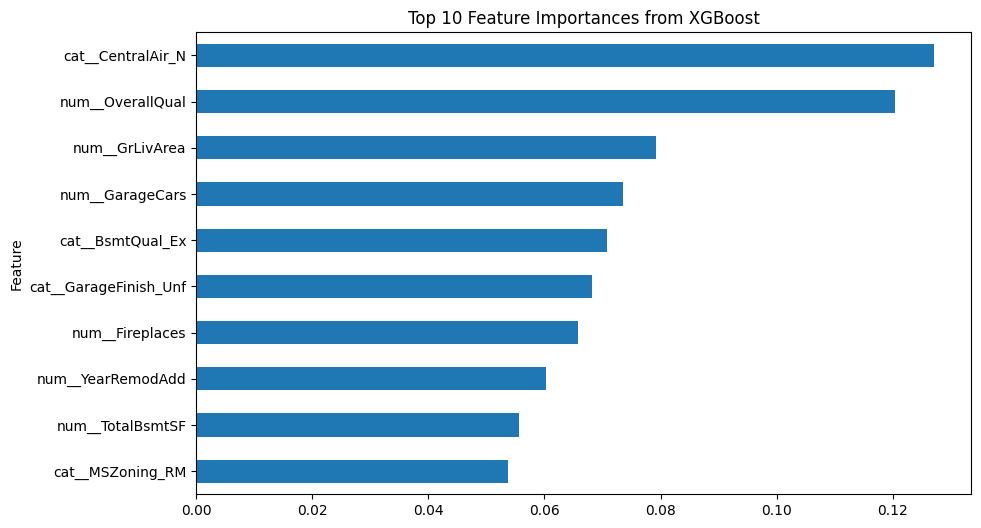

In [102]:
## extrapolating the most important features from the XGBoost model ##
xgb_importances = GS_xgb.best_estimator_.named_steps['model'].feature_importances_
feature_names = GS_xgb.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
top_features = feature_importance_df.head(10).set_index('Feature')['Importance']
top_features[::-1].plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Feature Importances from XGBoost')

**The most important features of our XGBoost model were**
1) The existence of central a/c
2) The overall quality of the house
3) Above grade (ground) living area square feet
4) Number of cars the garage will fit
5) Basement Quality